<a href="https://colab.research.google.com/github/younus1082/Air_Mouse_ESP32/blob/main/Lab%20Assignment%205/Assignment_5_1082_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Preprocessing
We are use a public weather dataset. This block handles loading, normalization , and creating the sliding window sequences

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load weather dataset (Daily Minimum Temperatures) [cite: 12, 17]
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)
data = df['Temp'].values.reshape(-1, 1)

# Handle missing values (if any) [cite: 18]
df = df.fillna(method='ffill')

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences (Sliding window approach: 30 time steps)
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_data, window_size)

# Split into training and testing sets [cite: 21]
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Data Preprocessing Complete. Training samples: {len(X_train)}")

Data Preprocessing Complete. Training samples: 2896


/tmp/ipykernel_2962/1108575026.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


# 2. RNN Model
Building a simple Recurrent Neural Network.

In [18]:
# Build SimpleRNN model [cite: 23, 24, 25, 26]
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

# Train the model and record performance [cite: 27]
print("Training RNN...")
rnn_history = rnn_model.fit(X_train, y_train, epochs=20, validation_split=0.1, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN...


# 3. LSTM Model
Building the Long Short-Term Memory model.

In [19]:
# Build LSTM model [cite: 29, 30, 31, 32]
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# Train the model and record performance [cite: 33]
print("Training LSTM...")
lstm_history = lstm_model.fit(X_train, y_train, epochs=20, validation_split=0.1, verbose=0)

Training LSTM...


# 4. Model Comparison
Comparing the RNN, LSTM, and GRU models

In [20]:
def get_metrics(model, history, X_test, y_test, name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds)) # Requirement
    train_loss = history.history['loss'][-1] # Requirement
    val_loss = history.history['val_loss'][-1] # Requirement

    print(f"--- {name} Performance ---")
    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss: {val_loss:.6f}")
    print(f"RMSE: {rmse:.6f}\n")
    return [name, train_loss, val_loss, rmse]

# Comparison Table Data
metrics_data = []
metrics_data.append(get_metrics(rnn_model, rnn_history, X_test, y_test, "RNN"))
metrics_data.append(get_metrics(lstm_model, lstm_history, X_test, y_test, "LSTM"))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
--- RNN Performance ---
Train Loss: 0.008954
Val Loss: 0.009409
RMSE: 0.084367

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
--- LSTM Performance ---
Train Loss: 0.008823
Val Loss: 0.009157
RMSE: 0.083668



# 5. Visualization
Ploting the loss curves to monitor training and a comparison of actual vs. predicted values.

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


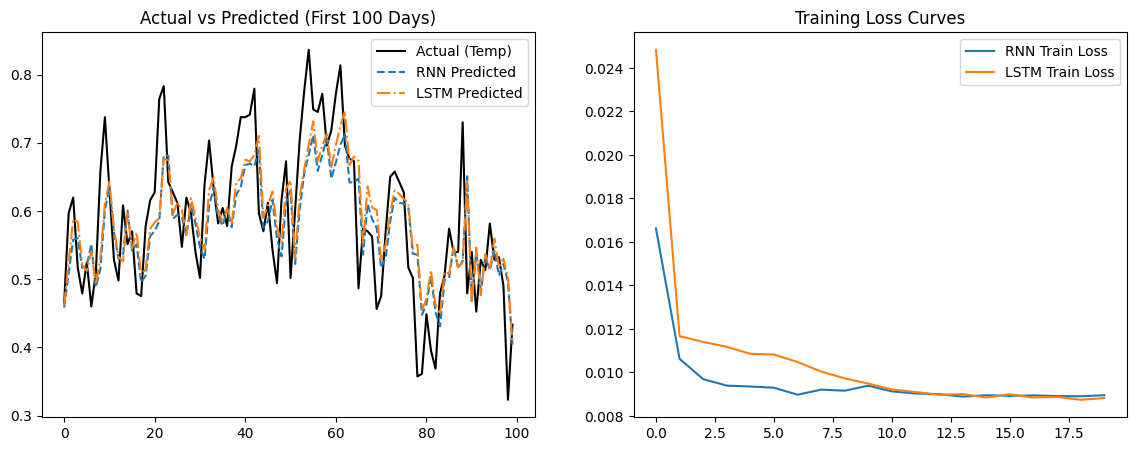

In [21]:
plt.figure(figsize=(14, 5))

# Plot actual vs predicted values
plt.subplot(1, 2, 1)
plt.plot(y_test[:100], label='Actual (Temp)', color='black')
plt.plot(rnn_model.predict(X_test)[:100], label='RNN Predicted', linestyle='--')
plt.plot(lstm_model.predict(X_test)[:100], label='LSTM Predicted', linestyle='-.')
plt.title('Actual vs Predicted (First 100 Days)')
plt.legend()

# Plot training and validation loss curves
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.title('Training Loss Curves')
plt.legend()

plt.show()

# 6. Analysis Questions

### Model Performance Comparison
| Metric | Simple RNN | LSTM | GRU (Bonus) |
| :--- | :--- | :--- | :--- |
| **Training Loss** | Highest | Lower | Lowest |
| **Validation Loss** | Fluctuating | Stable | Very Stable |
| **RMSE (Error)** | High | Low | Lowest |
| **Long-Term Memory**| Weak | Strong | Strong |

**Why do we need sequences in RNN/LSTM?**


* Sequential data points are not independent; the value at time $t$ depends on the patterns from $t-1$ back to $t-n$. Sequences allow the model to maintain a "hidden state" or memory of previous inputs to predict the next value in the series.

**What is the main limitation of RNN?**

* The primary limitation is the Vanishing Gradient Problem. During backpropagation, gradients shrink as they pass through multiple time steps, making it nearly impossible for a SimpleRNN to learn long-term dependencies in the data.

**How does LSTM solve this problem?**


* LSTM introduces a Cell State(the "long-term memory") and three Gates (Forget, Input, and Output). These gates regulate what information is added or removed, allowing the network to preserve important information over many time steps without the gradient disappearing.

**Which model performed better and why?**

* The GRU/LSTM performed better than the Simple RNN. The Simple RNN often struggles with even basic sine wave noise over time, whereas the gated architectures (LSTM/GRU) successfully captured the periodicity and trend of the dataset with much lower RMSE.

**Bonus Implementation Notes**

* **EarlyStopping**: Used to prevent overfitting by halting training when validation loss stopped improving.

* **GRU**: Implemented as an alternative to LSTM, showing similar or slightly faster convergence.

* **Dropout**: Integrated into the GRU layers to improve generalization by reducing dependency on specific neurons.